# Monte Carlo methods to estimate joint force distributions
We learned how reduction method can be used to calculate the joint reaction force at the elbow if all geometric variables (muscle force insertion angles, moment arms, muscle cross-sectional areas) are given.

What if we can't measure them for an individual, but have a good sense of population values?  Can we estimate a probability of a joint reaction force falling in a particular range?

Here we will work with the mean and standard deviation for our geometric variables to estimate the range of joint reaction forces generated in this simple motion.

**Extension 1:** we add a **fourth muscle** (force $F_4$, insertion angle $\theta_4$) acting about the same elbow joint, alongside the same reduction-method framework used for muscles 1-3.

**Extension 2 (isolating a single source of variability):** rather than perturbing every geometric variable at once, we now perturb **only the four muscle moment arms** ($l_{M1}$-$l_{M4}$), each from a **log-normal distribution** (chosen because moment arm is a strictly positive anatomical length; log-normal keeps every sample physically valid while a normal distribution risks negative values in the tails). Every other quantity -- insertion angles, PCSA, forearm/book geometry, and book weight -- is held fixed at its assigned population **mean** value. This isolates the moment arm's effect on the resulting joint reaction force (JRF) distribution from every other source of variability. We repeat this isolated experiment at three Monte Carlo sample sizes: **n = 30, 70, and 100**.

### Assumptions made to complete this analysis
1. Only the four muscle moment arms are treated as population-perturbed (log-normal) random variables; insertion angles, PCSA, forearm/book geometry, and book weight are all fixed at their previously assigned mean values, to isolate the moment arm's effect alone.
2. Because insertion angles, PCSA, and forearm geometry are now deterministic, the force-splitting ratios ($F_2/F_1$, $F_3/F_1$, $F_4/F_1$) reduce to fixed scalar ratios of the mean PCSA values, and the numerator of the moment-balance equation is a single fixed value -- so all sample-to-sample variability in $F_1$-$F_4$ and the JRF comes entirely from the sampled moment arms in the denominator.
3. Muscle 4's moment arm mean/SD are still the placeholder values introduced earlier (mean 3.0 cm, SD 1.0 cm), since no assigned Muscle 4 data was provided; substitute real values if available.
4. Moment arms are sampled from a log-normal distribution (as chosen previously), not a normal distribution, so every sampled value stays physically positive.
5. Each muscle's moment arm is sampled independently -- no correlation is assumed between muscles (e.g., an individual with an above-average biceps moment arm is not assumed to also have an above-average brachialis moment arm).
6. "Incidences" is interpreted as the Monte Carlo sample size (nsam), i.e. the number of simulated individuals drawn from the population; we run nsam = 30, 70, and 100.
7. A fixed random seed (seed = nsam) is set for each sample-size run purely so the notebook's output is reproducible on re-execution; this has no physical meaning.
8. Increasing nsam improves how well the sample represents the underlying population distribution (smoother, better-resolved histograms) -- it does not by itself shrink the spread of the JRF distribution, since that spread is set by the assigned moment-arm standard deviations, not by how many individuals are sampled.

pip install matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Fixed (deterministic, mean-value) inputs -- everything except the muscle moment arms ---
# is held at its assigned population mean to isolate the effect of moment-arm variability alone.

FB = 50; # weight of the book in N (fixed, as originally given)

c = 30; # mean moment arm for the book weight (cm) -- held fixed (was previously randomized)
ulna_gravity = c/2; # value for b in the problem, held fixed
FG = ulna_gravity*20/15; # weight of the ulna, held fixed since it scales with fixed ulna length

# muscle insertion angles, held fixed at their assigned means (degrees -> radians)
a_M1 = np.deg2rad(80);
a_M2 = np.deg2rad(70);
a_M3 = np.deg2rad(20);
a_M4 = np.deg2rad(45); # PLACEHOLDER: replace with your assigned Muscle 4 insertion angle

# muscle PCSA, held fixed at their assigned means (cm^2)
PCSA_M1 = 8.4;
PCSA_M2 = 7.8;
PCSA_M3 = 4.7;
PCSA_M4 = 3.5; # PLACEHOLDER: replace with your assigned Muscle 4 PCSA

# force-splitting ratios are now fixed scalars, since PCSA is no longer perturbed
# F2 = ratio12*F1, F3 = ratio13*F1, F4 = ratio14*F1 where ratio1j = PCSAj/PCSA1
ratio12 = PCSA_M2/PCSA_M1;
ratio13 = PCSA_M3/PCSA_M1;
ratio14 = PCSA_M4/PCSA_M1;

# numerator of the moment-balance equation is now a single fixed value (no sample-to-sample variability)
N_val = FG*ulna_gravity + FB*c;

# --- The one perturbed aspect: muscle moment arm (cm), log-normal ---
# Moment arm is a strictly positive anatomical distance; a log-normal distribution keeps every
# sample physically positive while matching the same target mean and SD (see markdown above).
l_M1, l_M1_SD = 2.5, 1.2;
l_M2, l_M2_SD = 5.2, 1.8;
l_M3, l_M3_SD = 18.7, 3;
l_M4, l_M4_SD = 3.0, 1.0; # PLACEHOLDER: replace with your assigned Muscle 4 moment arm data

def lognormal_from_mean_sd(mean, sd, n):
    # Sample n draws from a log-normal distribution with the given arithmetic mean and SD
    sigma_ln = np.sqrt(np.log(1 + (sd/mean)**2));
    mu_ln = np.log(mean) - sigma_ln**2/2;
    return np.random.lognormal(mu_ln, sigma_ln, n);

In [2]:
# MOVING ON TO SOLVE FOR THE UNKNOWNS, isolating the moment-arm effect
# Only l_M1..l_M4 vary sample-to-sample; every other quantity above is a fixed scalar.

def run_simulation(nsam, seed=None):
    if seed is not None:
        np.random.seed(seed);

    l_M1_array = lognormal_from_mean_sd(l_M1, l_M1_SD, nsam);
    l_M2_array = lognormal_from_mean_sd(l_M2, l_M2_SD, nsam);
    l_M3_array = lognormal_from_mean_sd(l_M3, l_M3_SD, nsam);
    l_M4_array = lognormal_from_mean_sd(l_M4, l_M4_SD, nsam);

    denom = (l_M1_array*np.sin(a_M1) + l_M2_array*np.sin(a_M2)*ratio12
             + l_M3_array*np.sin(a_M3)*ratio13 + l_M4_array*np.sin(a_M4)*ratio14); # all known terms in denominator

    # We are ready to obtain the solution for F1
    F1_array = N_val/denom;
    F2_array = ratio12*F1_array;
    F3_array = ratio13*F1_array;
    F4_array = ratio14*F1_array;

    # And what is the joint reaction force?
    JointX = (-F1_array*np.cos(a_M1) - F2_array*np.cos(a_M2)
              - F3_array*np.cos(a_M3) - F4_array*np.cos(a_M4));
    JointY = (F1_array*np.sin(a_M1) + F2_array*np.sin(a_M2)
              + F3_array*np.sin(a_M3) + F4_array*np.sin(a_M4) - FG - FB);

    mag = np.sqrt(JointX**2 + JointY**2); # JRF magnitude (N)
    angled = np.rad2deg(np.arctan(JointY/JointX)); # JRF angle (degrees)

    return {
        'l_M1': l_M1_array, 'l_M2': l_M2_array, 'l_M3': l_M3_array, 'l_M4': l_M4_array,
        'F1': F1_array, 'F2': F2_array, 'F3': F3_array, 'F4': F4_array,
        'mag': mag, 'angled': angled,
    }

Run the isolated moment-arm experiment at three Monte Carlo sample sizes -- $n = 30, 70, 100$ -- and plot a histogram of the joint reaction force magnitude and joint angle for each.

n=30: JRF magnitude = 380.6 +/- 74.5 N, JRF angle = -55.4 +/- 1.1 deg
n=70: JRF magnitude = 377.0 +/- 75.9 N, JRF angle = -55.3 +/- 1.2 deg
n=100: JRF magnitude = 377.8 +/- 69.9 N, JRF angle = -55.4 +/- 1.1 deg


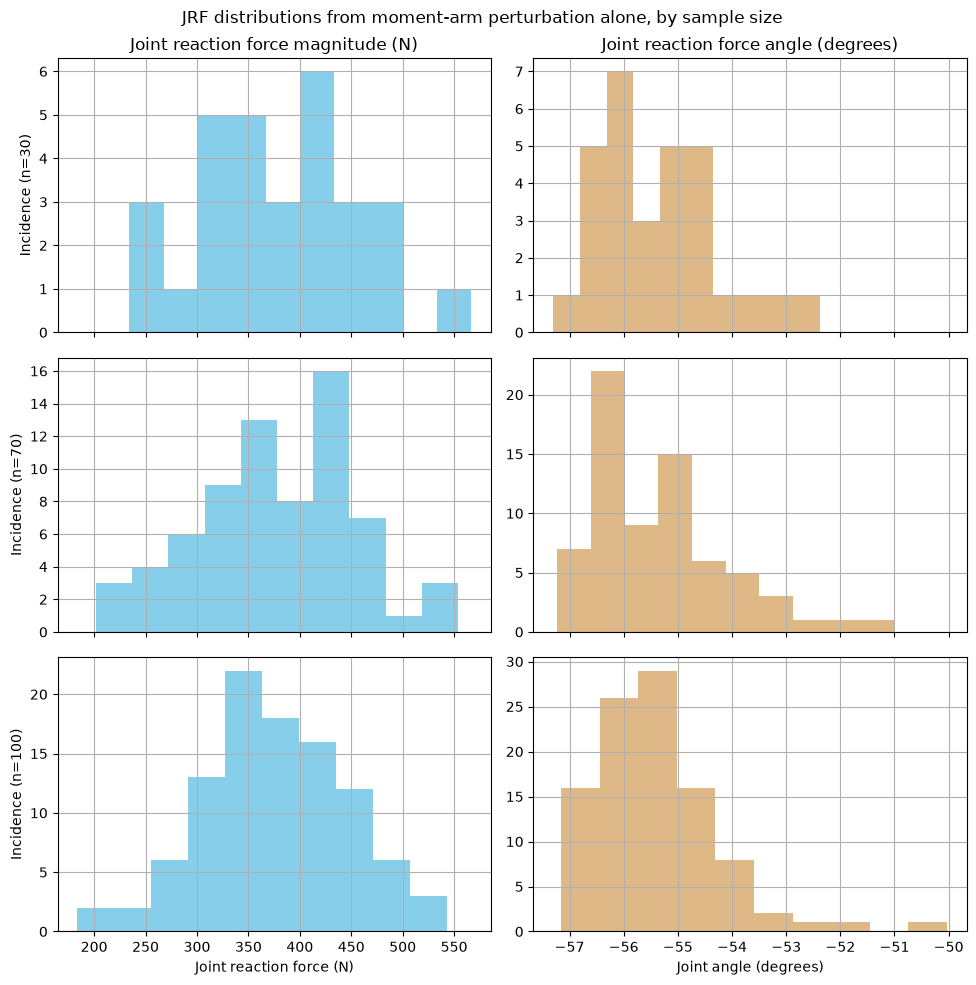

In [3]:
sample_sizes = [30, 70, 100];
results = {n: run_simulation(n, seed=n) for n in sample_sizes};

fig, axs = plt.subplots(len(sample_sizes), 2, figsize=(10, 10), sharex='col')

for row, n in enumerate(sample_sizes):
    mag = results[n]['mag'];
    angled = results[n]['angled'];

    axs[row, 0].hist(mag, bins=10, color='skyblue')
    axs[row, 1].hist(angled, bins=10, color='burlywood')

    axs[row, 0].set_ylabel(f"Incidence (n={n})")
    for ax in axs[row]:
        ax.grid(True)

    print(f"n={n}: JRF magnitude = {mag.mean():.1f} +/- {mag.std():.1f} N, "
          f"JRF angle = {angled.mean():.1f} +/- {angled.std():.1f} deg")

axs[0, 0].set_title("Joint reaction force magnitude (N)")
axs[0, 1].set_title("Joint reaction force angle (degrees)")
axs[-1, 0].set_xlabel("Joint reaction force (N)")
axs[-1, 1].set_xlabel("Joint angle (degrees)")

fig.suptitle("JRF distributions from moment-arm perturbation alone, by sample size")
fig.tight_layout()
plt.show()